Hormone Levels Trend

In [67]:
# Import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [68]:
# Hormone Levels Trends Dataset
df = pd.read_csv(r"C:\Users\crowd\Downloads\DTSC 4301 Datasets\hormone levels trends\hormone_levels_trends.csv")

In [69]:
# Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Record_ID                 8000 non-null   object 
 1   Age                       8000 non-null   int64  
 2   Year                      8000 non-null   int64  
 3   Testosterone_Level_ng_dl  8000 non-null   float64
 4   Estrogen_Level_pmol_l     8000 non-null   float64
 5   BMI                       8000 non-null   float64
 6   Exercise_Frequency        6401 non-null   object 
 7   Stress_Level              8000 non-null   object 
 8   Smoking_Status            8000 non-null   object 
 9   Alcohol_Consumption       4775 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 625.1+ KB


In [70]:
#Checking the dataset
df.head(10)

,Record_ID,Age,Year,Testosterone_Level_ng_dl,Estrogen_Level_pmol_l,BMI,Exercise_Frequency,Stress_Level,Smoking_Status,Alcohol_Consumption
0,R00001,56,2023,520.2,43.2,20.3,NaN,Moderate,Non-Smoker,Occasional
1,R00002,46,2004,611.5,30.1,22.8,Low,Low,Current Smoker,NaN
2,R00003,32,2019,466.2,48.6,18.1,Low,Moderate,Non-Smoker,Regular
3,R00004,60,2006,551.3,37.9,29.8,Low,Moderate,Current Smoker,Regular
4,R00005,25,2006,563.0,31.3,27.1,Low,Low,Current Smoker,NaN
5,R00006,38,2012,527.7,35.4,21.6,NaN,Moderate,Non-Smoker,NaN
6,R00007,56,2008,521.6,38.6,23.0,Moderate,Moderate,Non-Smoker,NaN
7,R00008,36,2024,516.6,47.7,28.0,Moderate,Moderate,Former Smoker,Regular
8,R00009,40,2020,561.6,47.4,30.1,NaN,Low,Non-Smoker,Occasional
9,R00010,28,2012,551.6,38.8,25.4,Low,High,Non-Smoker,Occasional


In [71]:
#Dropping Unnecessary columns
df = df.drop(columns=['Record_ID'])

In [72]:
#Checking Updated dataset
df.head(10)

,Age,Year,Testosterone_Level_ng_dl,Estrogen_Level_pmol_l,BMI,Exercise_Frequency,Stress_Level,Smoking_Status,Alcohol_Consumption
0,56,2023,520.2,43.2,20.3,NaN,Moderate,Non-Smoker,Occasional
1,46,2004,611.5,30.1,22.8,Low,Low,Current Smoker,NaN
2,32,2019,466.2,48.6,18.1,Low,Moderate,Non-Smoker,Regular
3,60,2006,551.3,37.9,29.8,Low,Moderate,Current Smoker,Regular
4,25,2006,563.0,31.3,27.1,Low,Low,Current Smoker,NaN
5,38,2012,527.7,35.4,21.6,NaN,Moderate,Non-Smoker,NaN
6,56,2008,521.6,38.6,23.0,Moderate,Moderate,Non-Smoker,NaN
7,36,2024,516.6,47.7,28.0,Moderate,Moderate,Former Smoker,Regular
8,40,2020,561.6,47.4,30.1,NaN,Low,Non-Smoker,Occasional
9,28,2012,551.6,38.8,25.4,Low,High,Non-Smoker,Occasional


In [73]:
#Checking for missing values
print(df.isnull().sum())

Age                            0
Year                           0
Testosterone_Level_ng_dl       0
Estrogen_Level_pmol_l          0
BMI                            0
Exercise_Frequency          1599
Stress_Level                   0
Smoking_Status                 0
Alcohol_Consumption         3225
dtype: int64


In [74]:
#Checking Exercise_Frequency rows for missing values
df[df['Exercise_Frequency'].isnull()]

,Age,Year,Testosterone_Level_ng_dl,Estrogen_Level_pmol_l,BMI,Exercise_Frequency,Stress_Level,Smoking_Status,Alcohol_Consumption
0,56,2023,520.2,43.2,20.3,NaN,Moderate,Non-Smoker,Occasional
5,38,2012,527.7,35.4,21.6,NaN,Moderate,Non-Smoker,NaN
8,40,2020,561.6,47.4,30.1,NaN,Low,Non-Smoker,Occasional
14,41,2000,557.2,31.7,20.3,NaN,Moderate,Current Smoker,Regular
19,61,2012,563.3,43.9,24.3,NaN,Low,Non-Smoker,NaN
...,...,...,...,...,...,...,...,...,...
7982,34,2020,537.8,48.1,27.0,NaN,Low,Current Smoker,Occasional
7987,58,2011,567.2,34.5,26.9,NaN,Moderate,Current Smoker,NaN
7992,60,2013,515.9,46.8,34.6,NaN,Moderate,Non-Smoker,Occasional
7996,60,2018,482.4,43.5,25.3,NaN,High,Non-Smoker,NaN


In [75]:
#Changing all missing values in Exercise_Type to 'None'
df['Exercise_Frequency'] = df['Exercise_Frequency'].fillna('None')

In [76]:
#Checking Alcohol_Consumption rows for missing values
df[df['Alcohol_Consumption'].isnull()]

,Age,Year,Testosterone_Level_ng_dl,Estrogen_Level_pmol_l,BMI,Exercise_Frequency,Stress_Level,Smoking_Status,Alcohol_Consumption
1,46,2004,611.5,30.1,22.8,Low,Low,Current Smoker,NaN
4,25,2006,563.0,31.3,27.1,Low,Low,Current Smoker,NaN
5,38,2012,527.7,35.4,21.6,None,Moderate,Non-Smoker,NaN
6,56,2008,521.6,38.6,23.0,Moderate,Moderate,Non-Smoker,NaN
11,41,2012,550.7,41.9,18.5,Moderate,High,Non-Smoker,NaN
...,...,...,...,...,...,...,...,...,...
7985,52,2008,607.1,31.5,25.1,Low,High,Non-Smoker,NaN
7987,58,2011,567.2,34.5,26.9,None,Moderate,Current Smoker,NaN
7996,60,2018,482.4,43.5,25.3,None,High,Non-Smoker,NaN
7997,20,2011,527.9,35.3,31.5,None,High,Non-Smoker,NaN


In [77]:
#Changing all missing values in Exercise_Type to 'None'
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].fillna('None')

In [78]:
#checking the results of the changes
df.head(10)

,Age,Year,Testosterone_Level_ng_dl,Estrogen_Level_pmol_l,BMI,Exercise_Frequency,Stress_Level,Smoking_Status,Alcohol_Consumption
0,56,2023,520.2,43.2,20.3,None,Moderate,Non-Smoker,Occasional
1,46,2004,611.5,30.1,22.8,Low,Low,Current Smoker,None
2,32,2019,466.2,48.6,18.1,Low,Moderate,Non-Smoker,Regular
3,60,2006,551.3,37.9,29.8,Low,Moderate,Current Smoker,Regular
4,25,2006,563.0,31.3,27.1,Low,Low,Current Smoker,None
5,38,2012,527.7,35.4,21.6,None,Moderate,Non-Smoker,None
6,56,2008,521.6,38.6,23.0,Moderate,Moderate,Non-Smoker,None
7,36,2024,516.6,47.7,28.0,Moderate,Moderate,Former Smoker,Regular
8,40,2020,561.6,47.4,30.1,None,Low,Non-Smoker,Occasional
9,28,2012,551.6,38.8,25.4,Low,High,Non-Smoker,Occasional


In [79]:
# Checking the results of the changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       8000 non-null   int64  
 1   Year                      8000 non-null   int64  
 2   Testosterone_Level_ng_dl  8000 non-null   float64
 3   Estrogen_Level_pmol_l     8000 non-null   float64
 4   BMI                       8000 non-null   float64
 5   Exercise_Frequency        8000 non-null   object 
 6   Stress_Level              8000 non-null   object 
 7   Smoking_Status            8000 non-null   object 
 8   Alcohol_Consumption       8000 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 562.6+ KB


Hormone Levels Trends Line Plot

In [80]:
# Grouping by Year and calculating the average Testosterone and Estrogen levels
yearly_avg = df.groupby('Year')[["Testosterone_Level_ng_dl", "Estrogen_Level_pmol_l"]].mean()

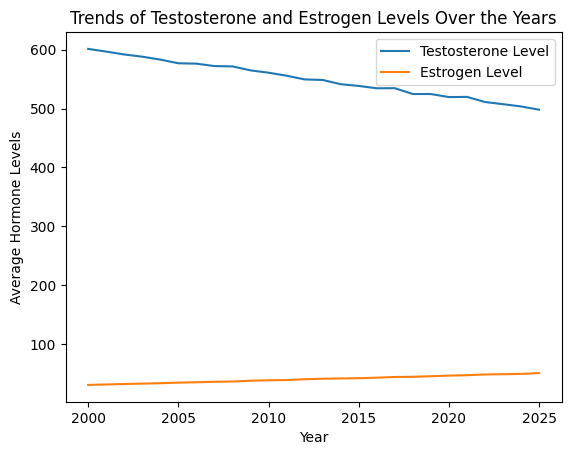

In [81]:
# Plotting the trends of Testosterone and Estrogen levels over the years
plt.figure()
plt.plot(yearly_avg.index, yearly_avg["Testosterone_Level_ng_dl"], label="Testosterone Level")
plt.plot(yearly_avg.index, yearly_avg["Estrogen_Level_pmol_l"], label="Estrogen Level")

# Adding labels and title
plt.xlabel("Year")
plt.ylabel("Average Hormone Levels")
plt.title("Trends of Testosterone and Estrogen Levels Over the Years")
plt.legend()
plt.show()

Stratified Analysis

In [82]:
# Creating BMI groups
df["BMI_Group"] = pd.cut(df["BMI"],
                        bins=[0, 25, 30, 100],
                        labels=["Normal", "Overweight", "Obese"])

C:\Users\crowd\AppData\Local\Temp\ipykernel_21124\2442297906.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["Year", "BMI_Group"])["Testosterone_Level_ng_dl"].mean().unstack()


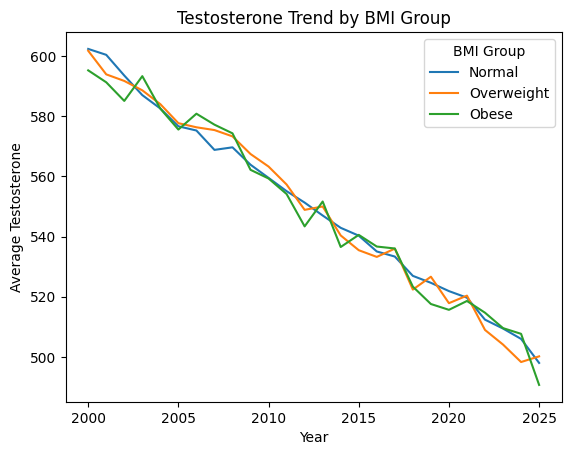

In [83]:
# Grouping by Year and BMI Group, then calculating the average Testosterone levels
grouped = df.groupby(["Year", "BMI_Group"])["Testosterone_Level_ng_dl"].mean().unstack()

grouped.plot()

plt.xlabel("Year")
plt.ylabel("Average Testosterone")
plt.title("Testosterone Trend by BMI Group")
plt.legend(title="BMI Group")

plt.show()

Decision Tree

In [84]:
# Preparing the data for modeling
X = pd.get_dummies(df[[
    "Year", "Age", "BMI",
    "Exercise_Frequency",
    "Stress_Level",
    "Smoking_Status",
    "Alcohol_Consumption"
]], drop_first=True)

y = df["Testosterone_Level_ng_dl"]

In [85]:
#Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Train Decision Tree model
model = DecisionTreeRegressor(
    max_depth=4,      
    random_state=42
)
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)

R2 Score: 0.49227482131407596
MSE: 923.9937155107793


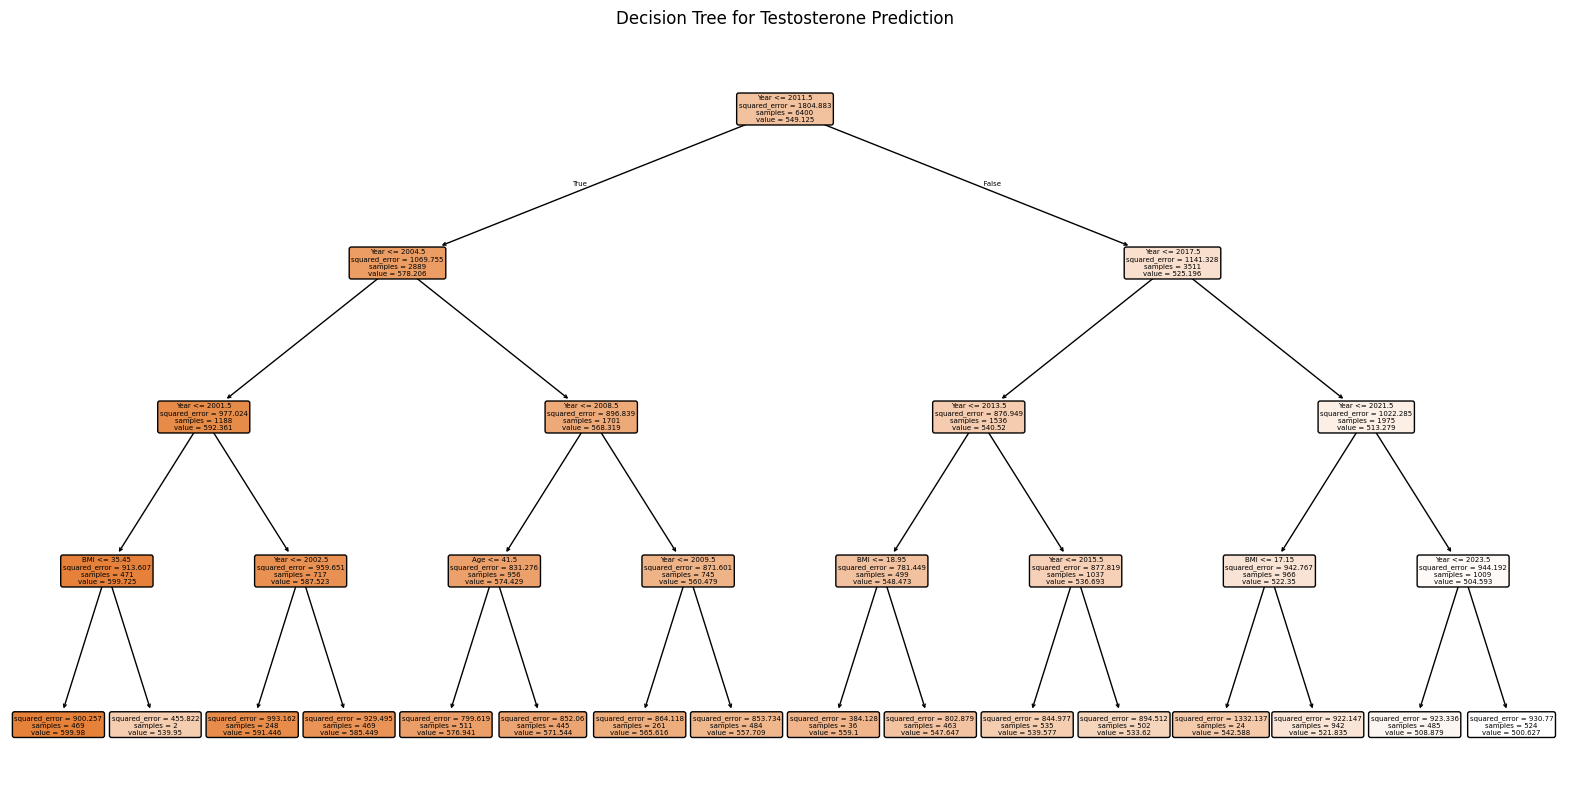

In [86]:
#Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

#Visualize the tree
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Testosterone Prediction")
plt.show()

In [87]:
#Feature importance from Decision Tree
dt_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(dt_importance)

Year                              0.995156
BMI                               0.003670
Age                               0.001175
Exercise_Frequency_Low            0.000000
Exercise_Frequency_Moderate       0.000000
Exercise_Frequency_None           0.000000
Stress_Level_Low                  0.000000
Stress_Level_Moderate             0.000000
Smoking_Status_Former Smoker      0.000000
Smoking_Status_Non-Smoker         0.000000
Alcohol_Consumption_Occasional    0.000000
Alcohol_Consumption_Regular       0.000000
dtype: float64


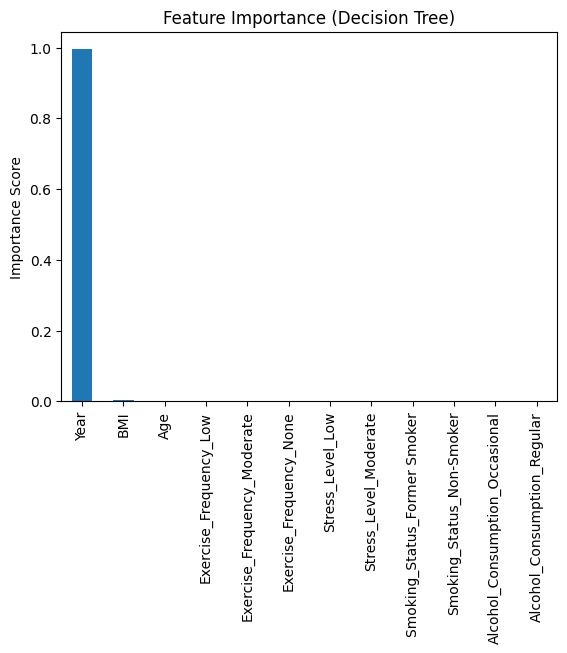

In [88]:
#Plotting feature importance
dt_importance.plot(kind="bar")

plt.title("Feature Importance (Decision Tree)")
plt.ylabel("Importance Score")
plt.show()

Random Forst

In [89]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,   
    max_depth=6,        
    random_state=42
)

rf_model.fit(X_train, y_train)

#Predicting with Random Forest
y_pred_rf = rf_model.predict(X_test)

In [90]:
#Evaluation of Random Forest
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest R2: 0.4956219640485747
Random Forest MSE: 917.9023515575499


In [91]:
#Feature importance from Random Forest
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Year                              0.936945
BMI                               0.032080
Age                               0.017873
Stress_Level_Low                  0.001705
Alcohol_Consumption_Regular       0.001688
Exercise_Frequency_None           0.001681
Alcohol_Consumption_Occasional    0.001514
Smoking_Status_Former Smoker      0.001436
Exercise_Frequency_Low            0.001417
Smoking_Status_Non-Smoker         0.001404
Stress_Level_Moderate             0.001282
Exercise_Frequency_Moderate       0.000974
dtype: float64


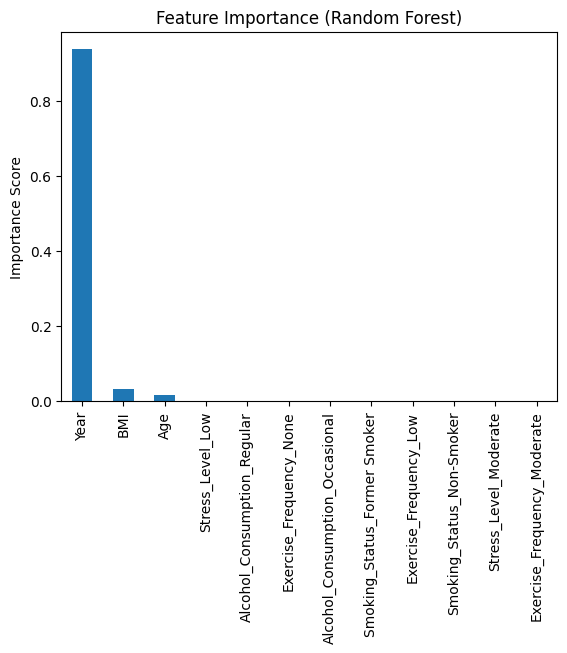

In [92]:
#Plotting feature importance
feature_importance.plot(kind="bar")

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

Clustering

In [93]:
#Key features identified by both models
features = ["Testosterone_Level_ng_dl", "Estrogen_Level_pmol_l", "BMI", "Age"]

In [94]:
#Clustering analysis using the key features
X_cluster = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

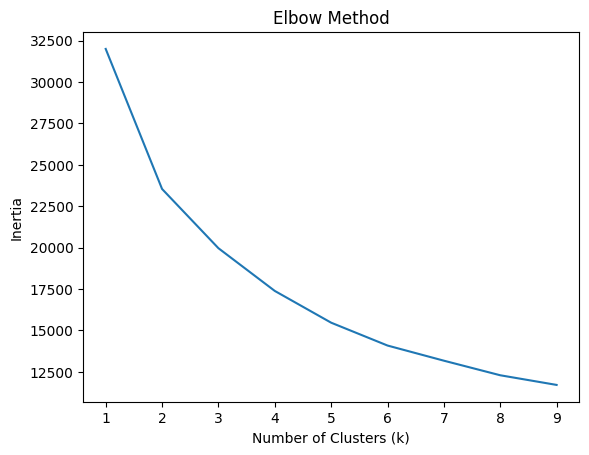

In [95]:
# Determine the optimal number of clusters using the Elbow Method
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [96]:
# Assign each data point to a cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [97]:
# Summarize the clusters
cluster_summary = df.groupby("Cluster")[features].mean()
print(cluster_summary)

         Testosterone_Level_ng_dl  Estrogen_Level_pmol_l        BMI        Age
Cluster                                                                       
0                      522.829261              45.210579  24.997145  29.347187
1                      586.221305              33.285958  25.062757  39.649422
2                      528.733919              43.869074  24.901476  54.108140


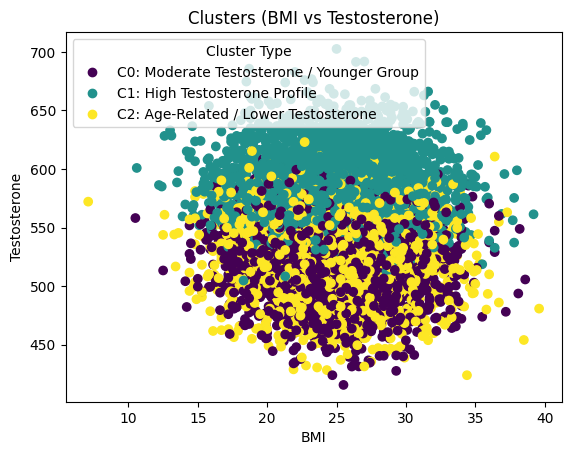

In [98]:
#Cluster visualization using BMI and Testosterone levels
labels = [
    "C0: Moderate Testosterone / Younger Group",
    "C1: High Testosterone Profile",
    "C2: Age-Related / Lower Testosterone"
]

scatter = plt.scatter(
    df["BMI"],
    df["Testosterone_Level_ng_dl"],
    c=df["Cluster"]
)

handles, _ = scatter.legend_elements()

plt.legend(handles, labels, title="Cluster Type")

plt.xlabel("BMI")
plt.ylabel("Testosterone")
plt.title("Clusters (BMI vs Testosterone)")

plt.show()